# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


**Data Frame Users**
- Las columnas con mas nulos son city(11%) y churn_date(88%)
- churn_date nos muestra la fecha que los clientes cancelaron el servicio, esto explica que el 88% sigue activo, por lo tanto a pesar que son valores nulos, estos nos dan informacion importante de los clientes que aun siguen usando de forma activa nuestros servicios, por lo tanto conservaria esos nulos. Merece mas la pena renombrarlos
- En cuanto a city, dado que el porcentaje es solo del 11% vale la pena investigar para imputarlos

**Data Frame Usage**

- duration y length, tienen valores nulos aproximadamente de 55% y 44% respectivamente
- duration tiene valores nulos en la columna tipo text, sin embargo, medir texto en terminos de duracion no tiene mucho sentido. Pasa lo mismo con los valores nulos de lenght en la columna de call, seria incorrecto medir la duracion de un mensaje de texto. Por lo tanto estos valores los eliminaria



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que
 encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- **La columna `user_id` :** No muestra registros atipicos o sentineles, la informacion generada es completamente normal.
- **La columna `age` :** Aqui si hay una inconsistencia, podemos ver que la edad minima es -999, esto a simple vista es un sentinel para trabajarlo mas adelante. a demas la desviacion estandar es muy alta atribuido al sentinel identificado.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- **Las columnas `id` y `user_id`**: muestran valores dentro de rangos normales
- Las columnas durantion and length son las que mas vale la pena revisar mas adelante ya que vale la pena revisar por que hay llamadas de 0 minutos al igual que textos equivalentes a 0 caracteres

In [14]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- {col} ---")
    print(users[col].unique())
    print()


--- city ---
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

--- plan ---
['Basico' 'Premium']



- La columna `city` : hay dos inconsistencias por revisar, ya que los valores "?" y "nan" no son los esperados en esta columna
- La columna `plan`: Muestra los dos valores esperados (Basico y Premium)

In [15]:

# explorar columna categórica de usage
columnas_usage = ['type']
for col in columnas_usage:
    print(f"--- {col} ---")
    print(usage[col].unique())
    print()


--- type ---
['call' 'text']



- La columna `type`: los valores categoricos de la columna usage son completamente normales y es lo esperado en esta columna


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

en la columna numerica "age" encontramos un sentinel con valor -999. Este debe ser revisado y posteriormente eliminado o reemplazado ya que no tiene sentido este valor
- ¿Qué acción tomarías?

por ahora lo mejor seria reemplazar estos valores por la mediana o promedio

  **¿En qué columnas encontraste valores inválidos o sentinels?**
- En la columna "city" encontramos valores invalidos tales como "?" y "nan"
- vale la pena analizarlos para eliminarlos y mejor reemplazarlos 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Todo esta en orden, excepto por los 40 registros del 2026

In [19]:

# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())



2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

- En este caso ya podemos estar seguros que los registros corresponden a los registros hasta el año 2024. los 50 egistros faltantes corresponden a valores nulos calculados anteriormente

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Si, aparecen 40 registros para el año 2026, ya que los registros representan a penas el 0.125% del total podriamos eliminarlos. 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:

# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].isna().sum())


565


In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > pd.Timestamp.today(), 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].isna().sum())

0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(pd.crosstab(usage['type'], usage['duration'].isna()))


duration  False  True 
type                  
call      17908      0
text         16  22076


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(pd.crosstab(usage['type'], usage['length'].isna()))


length  False  True 
type                
call       12  17896
text    22092      0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

- Deberiamos esperar un valor 0 en texto (False), ya que el texto no deberia tener ninguna duracion
- Lo mismo pasa en el segundo resultado, call deberia mostrar 0 registros en false, ya que no tiene sentido describir una llamada con cierto numero de caracteres.
- Para concluir, ya que estas inconsistencias representan un valor muy pequeño sobre el total, deberian ser reemplazadas por NaN y esto no afectaria a nuestro analisis final.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg({
        "duration": "sum",
        "length": "sum",
        "is_text": "sum",
        "is_call": "sum"
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,duration,length,is_text,is_call
0,10000,23.70,258.0,7,3
1,10001,33.18,226.0,5,10
2,10002,10.74,225.0,5,2


In [26]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)


,user_id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas
0,10000,23.70,258.0,7,3
1,10001,33.18,226.0,5,10
2,10002,10.74,225.0,5,2


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_minutos_llamada,length,cant_mensajes,cant_llamadas
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,23.70,258.0,7.0,3.0
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,33.18,226.0,5.0,10.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,10.74,225.0,5.0,2.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,8.99,530.0,11.0,3.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,8.01,229.0,4.0,3.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
print(user_profile[
    ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [29]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

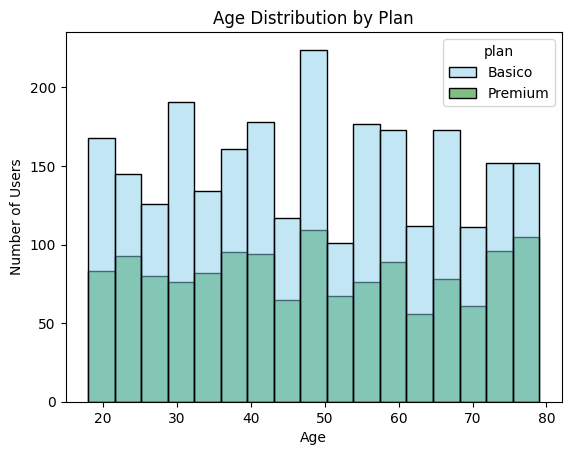

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Age Distribution by Plan')
plt.xlabel('Age')
plt.ylabel('Number of Users')

plt.show()

💡Insights: 
- A pesar de que el plan Básico cuenta con un mayor volumen total de clientes en comparación con el Premium, la distribución de edades en ambos planes es notablemente uniforme entre los 19 y 79 años. Esto demuestra un patrón de comportamiento muy similar entre ambos segmentos, indicando que ninguno de los planes está captando a un grupo de edad específico, sino que ambos atraen de manera equitativa a personas de todas las edades

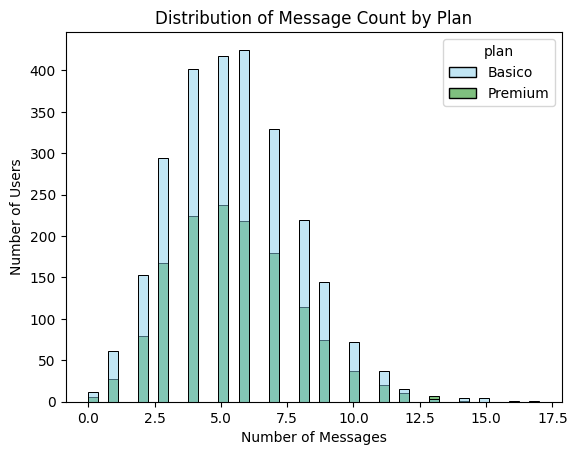

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribution of Message Count by Plan')
plt.xlabel('Number of Messages')
plt.ylabel('Number of Users')

plt.show()


💡Insights: 
- En cuanto al volumen de mensajes, el comportamiento es prácticamente idéntico en ambos planes: la gran mayoría de los usuarios envía entre 4 y 7 mensajes, y solo unos pocos envían una cantidad muy alta. Esto genera una distribución concentrada en los números bajos con una caída larga hacia los números más altos, lo que demuestra que contar con el plan Básico o el Premium no influye en la cantidad de mensajes que la gente suele mandar.

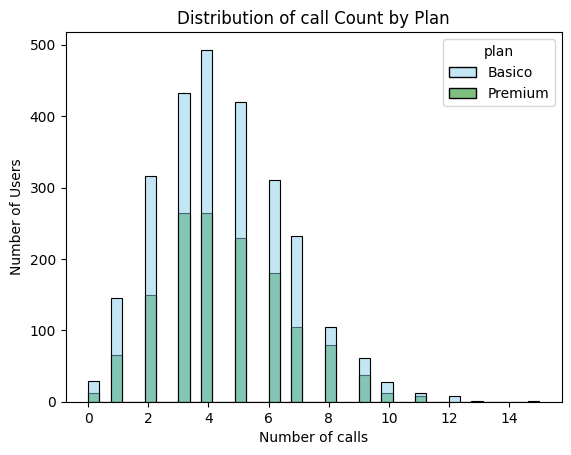

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribution of call Count by Plan')
plt.xlabel('Number of calls')
plt.ylabel('Number of Users')

plt.show()


💡Insights: 
- Respecto al número de llamadas, el comportamiento vuelve a ser muy similar entre ambos planes, ya que la gran mayoría de los usuarios realiza entre 3 y 6 llamadas durante el período analizado. Aunque el plan Básico muestra un mayor volumen de registros simplemente porque cuenta con más clientes en la base de datos, en ambos planes se repite la tendencia de que muy pocas personas realizan una cantidad elevada de llamadas (más de 10).

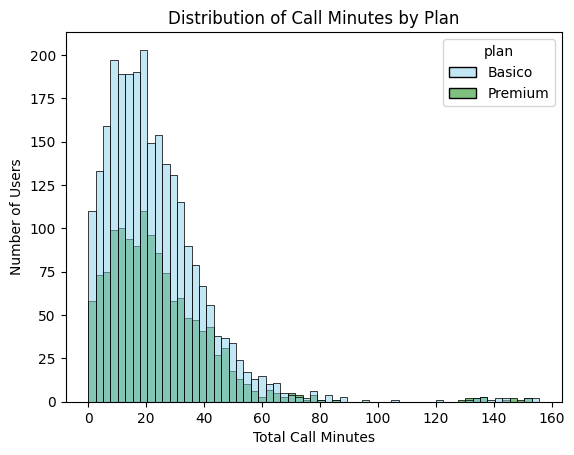

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribution of Call Minutes by Plan')
plt.xlabel('Total Call Minutes')
plt.ylabel('Number of Users')

plt.show()


💡Insights: 
- En cuanto a la duración de las llamadas, el comportamiento también es muy parecido entre ambos planes, con la gran mayoría de los usuarios acumulando menos de 40 minutos en total. Aunque el plan Básico concentra un mayor número de clientes simplemente porque tiene más usuarios en general, en ambos casos se nota que muy pocas personas registran consumos excepcionalmente altos que llegan casi a los 150 minutos, manteniendo la misma tendencia de uso general sin importar el plan contratado.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

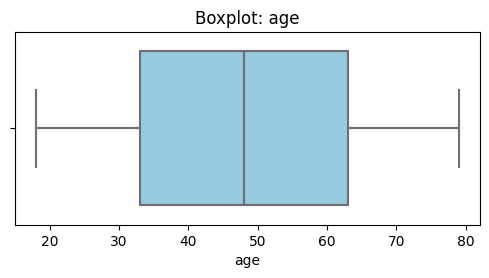

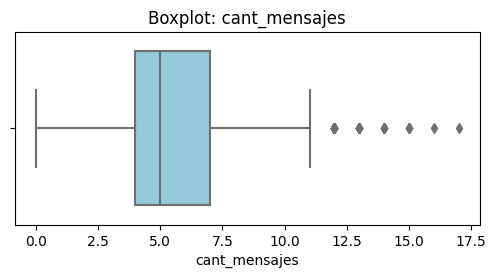

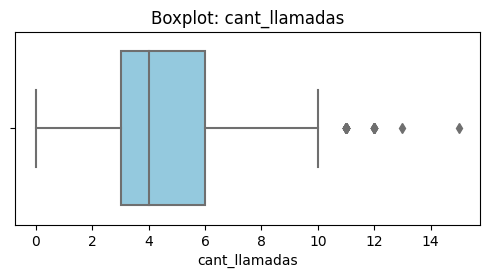

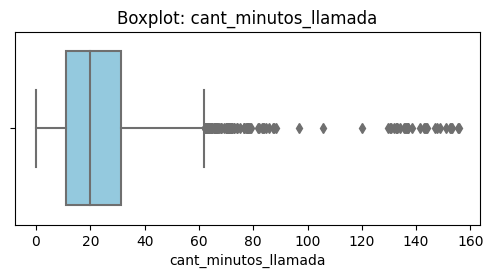

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 2.5))

    sns.boxplot(
        data=user_profile,
        x=col,
        color='skyblue'
    )

    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

    plt.show()

💡Insights: 
**- Age:**
El gráfico muestra que las edades están bastante equilibradas y no presentan valores extraños o fuera de lo común, lo que confirma que el reemplazo del dato inválido (-999) funcionó bien. La mitad de los usuarios tiene entre 35 y 62 años aproximadamente, con una edad media que se ubica cerca de los 48 años.

**- cant_mensajes:**
La mayoría de los usuarios envía entre 4 y 7 mensajes, aunque se identificaron algunos casos con una actividad muy alta por encima de los 11 mensajes. Estos valores representan comportamientos reales de usuarios más activos de lo normal, por lo que se recomienda mantenerlos en el análisis en lugar de eliminarlos.


**- cant_llamadas:**
La mayor parte de los usuarios realiza entre 3 y 6 llamadas, aunque se observan algunos casos aislados que superan las 11 llamadas. Al igual que ocurre con los mensajes, estos valores más altos reflejan un uso real y más activo del servicio por parte de ciertas personas, por lo que no se trata de errores en los datos.


**- cant_minutos_llamada:**
Los minutos totales de llamada representan la variable con la mayor cantidad de valores inusualmente altos, donde la gran mayoría de los usuarios acumula menos de 60 minutos en total. La distribución está muy concentrada en los valores bajos pero se estira hacia la derecha debido a que algunas personas superan los 100 o incluso 150 minutos; sin embargo, al ser un reflejo real de usuarios con un consumo muy elevado, se conservarán para el análisis.

In [35]:

# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'--- {col} ---')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite superior: {limite_superior}')
    print()



--- cant_mensajes ---
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5

--- cant_llamadas ---
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5

--- cant_minutos_llamada ---
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
**- cant_mensajes: mantener o no outliers, porqué?**
Mantener estos valores más altos porque, aunque tengo clientes que envían hasta 17 mensajes, este comportamiento es completamente lógico y real para usuarios muy activos. Al no detectar errores ni datos imposibles, preferí conservarlos para no perder información valiosa en el análisis.

**- cant_llamadas: mantener o no outliers, porqué?**
Mantener estos valores atípicos porque, aunque algunos usuarios realizan hasta 15 llamadas, considero que es una cantidad completamente razonable para un servicio de telefonía. Estos registros reflejan diferencias reales en el comportamiento de los clientes y no errores en la captura de los datos, por lo que conservarlos enriquece el análisis.

**- cant_minutos_llamada: mantener o no outliers, porqué?**
Mantener estos valores atípicos porque, aunque esta variable es la que presenta la mayor cantidad de ellos con usuarios que acumulan hasta 155.69 minutos de llamadas, es un comportamiento completamente esperable en clientes con un uso intensivo del servicio. 
Además, considero que conservarlos me será especialmente útil para analizar los patrones de consumo y entender mejor las diferencias entre los planes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,23.70,258.0,7.0,3.0,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,33.18,226.0,5.0,10.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,10.74,225.0,5.0,2.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,8.99,530.0,11.0,3.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,8.01,229.0,4.0,3.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
grupo_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

categorias = [
    'Joven',
    'Adulto'
]

user_profile['grupo_edad'] = np.select(
    grupo_edad,
    categorias,
    default='Adulto Mayor'
)

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,23.70,258.0,7.0,3.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,33.18,226.0,5.0,10.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,10.74,225.0,5.0,2.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,8.99,530.0,11.0,3.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,8.01,229.0,4.0,3.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

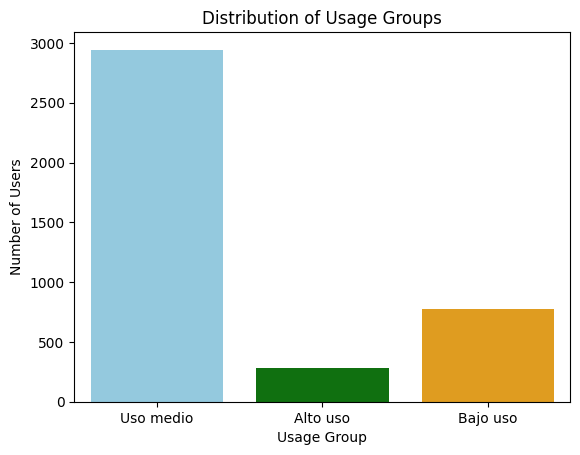

In [44]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['skyblue', 'green', 'orange']
)

plt.title('Distribution of Usage Groups')
plt.xlabel('Usage Group')
plt.ylabel('Number of Users')

plt.show()

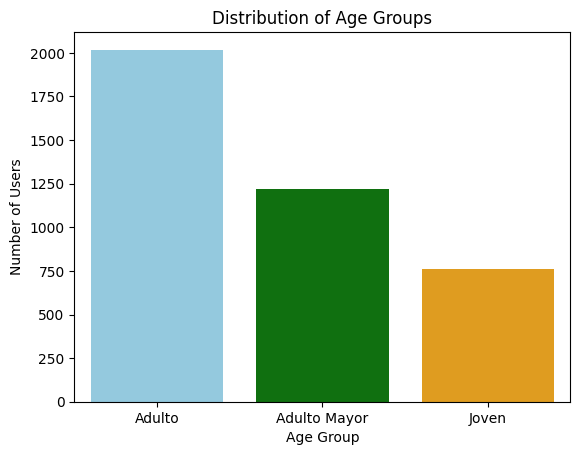

In [45]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette=['skyblue', 'green', 'orange']
)

plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna churn_date presentaba aproximadamente 88.3% de valores nulos. Debido a que estos casos corresponden a clientes que no han cancelado el servicio, se decidió conservar los valores nulos.
- La columna city tenía alrededor de 11.7% de valores faltantes, además de algunos registros con el valor "?", los cuales fueron tratados como datos faltantes.
- La columna age contenía un valor inválido (-999), el cual fue reemplazado por la mediana para evitar distorsionar el análisis.
- En el dataset usage, las columnas duration (55.2% de nulos) y length (44.7% de nulos) presentaban una alta cantidad de valores faltantes. Tras el análisis se determinó que estos correspondían a un patrón MAR (Missing At Random), ya que dependían del tipo de comunicación (llamadas o mensajes). Por esta razón, se mantuvieron como valores nulos.


🔍 **Segmentos por Edad**

Joven: menores de 30 años.
Adulto: entre 30 y 59 años.
Adulto Mayor: 60 años o más.

El análisis mostró que la mayor parte de los clientes pertenece al segmento de Adultos, lo que indica que este grupo representa la principal base de usuarios de ConnectaTel.

**Segmentación por nivel de uso**

Los clientes también fueron clasificados según su comportamiento de consumo:

Bajo uso: menos de 5 llamadas y menos de 5 mensajes.
Uso medio: menos de 10 llamadas y menos de 10 mensajes.
Alto uso: el resto de los usuarios.

La mayoría de los clientes se concentra en el segmento de Uso Medio, mientras que un grupo más reducido presenta un consumo considerablemente mayor.


**➡️ Esto sugiere que:**
- El segmento de Alto Uso representa una oportunidad comercial importante, ya que corresponde a clientes con un consumo significativamente superior al promedio.

- Aunque el análisis no incluye información de ingresos o rentabilidad por cliente, estos usuarios podrían beneficiarse de planes Premium o servicios adicionales, lo que representa una oportunidad para incrementar los ingresos mediante estrategias de fidelización y venta de productos de mayor valor.

- Asimismo, el segmento de Adultos merece especial atención, ya que concentra la mayor parte de la base de clientes y ofrece un alto potencial para campañas comerciales y programas de retención.

💡 **Recomendaciones**
Con base en los hallazgos obtenidos, se proponen las siguientes recomendaciones:

- Diseñar planes Premium dirigidos a clientes de alto consumo, ofreciendo mayores beneficios en minutos y mensajería.
Desarrollar campañas comerciales enfocadas en el segmento de adultos, que representa la mayor parte de la cartera de clientes.
- Implementar estrategias de fidelización para los usuarios de alto uso, con el fin de reducir la probabilidad de abandono y aumentar el valor del cliente.
- Mantener procesos periódicos de validación y limpieza de datos para garantizar la calidad de la información utilizada en futuros análisis.
- Utilizar la segmentación por edad y nivel de uso como base para diseñar ofertas personalizadas y mejorar la estrategia de comercialización.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`